# Data Understanding — MAD Dataset
Exploratory analysis for the AI Agent Evaluation Framework thesis.
Dataset: `MAD_full_dataset.json` (1 242 traces, 7 frameworks, 14 MAST failure modes)

In [5]:
import importlib.util
import json
import sys
import tempfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tiktoken
from transformers import AutoTokenizer

DATA_PATH = Path("..") / "data" / "MAST-Data" / "MAD_full_dataset.json"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [6]:
with open(DATA_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame([
    {
        "framework": d["mas_name"],
        "trace_id": d["trace_id"],
        "trajectory": d["trace"]["trajectory"],
        **{f"FM-{k}": v for k, v in d["mast_annotation"].items()},
    }
    for d in raw
])

FM_COLS = [c for c in df.columns if c.startswith("FM-")]
df["any_failure"] = df[FM_COLS].max(axis=1).astype(bool)

print(f"{len(df):,} traces | {df['framework'].nunique()} frameworks")
df.head(2)

1,242 traces | 7 frameworks


,framework,trace_id,trajectory,FM-1.1,FM-1.2,FM-1.3,FM-1.4,FM-1.5,FM-2.1,FM-2.2,FM-2.3,FM-2.4,FM-2.5,FM-2.6,FM-3.1,FM-3.2,FM-3.3,any_failure
0,ChatDev,0,[2025-31-03 19:09:41 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False
1,ChatDev,1,[2025-31-03 19:30:18 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False


## 1. Traces per framework & success / failure rate

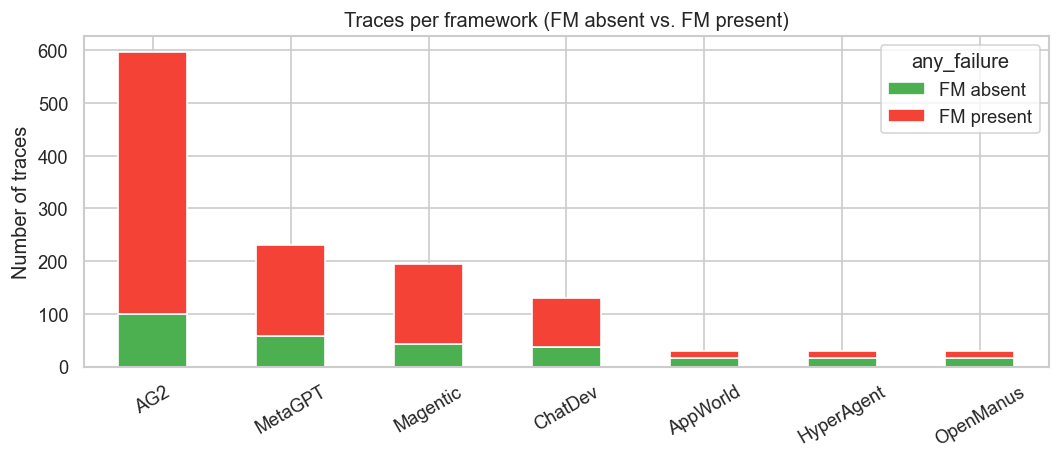

In [13]:
counts = (
    df.groupby(["framework", "any_failure"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "FM absent", True: "FM present"})
)
counts = counts.sort_values("FM present", ascending=False)

ax = counts.plot(kind="bar", stacked=True, figsize=(9, 4),
                 color=["#4CAF50", "#F44336"])
ax.set_title("Traces per framework (FM absent vs. FM present)")
ax.set_xlabel("")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_traces_per_framework.png")
plt.show()

## 2. Failure-mode prevalence

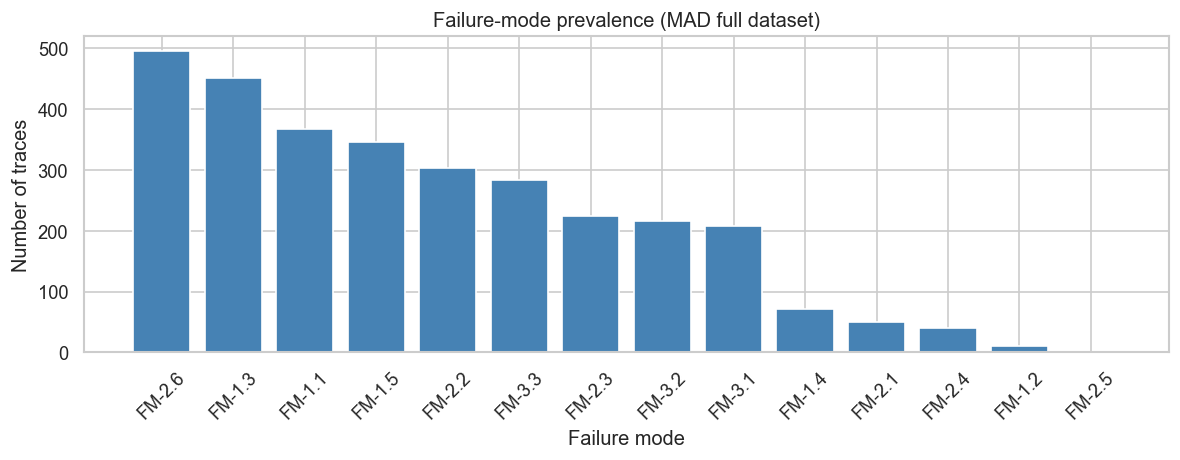

In [8]:
fm_counts = df[FM_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fm_counts.index, fm_counts.values, color="steelblue")
ax.set_title("Failure-mode prevalence (MAD full dataset)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("fig_fm_prevalence.png")
plt.show()

## 3. Failure-mode co-occurrence (heatmap)

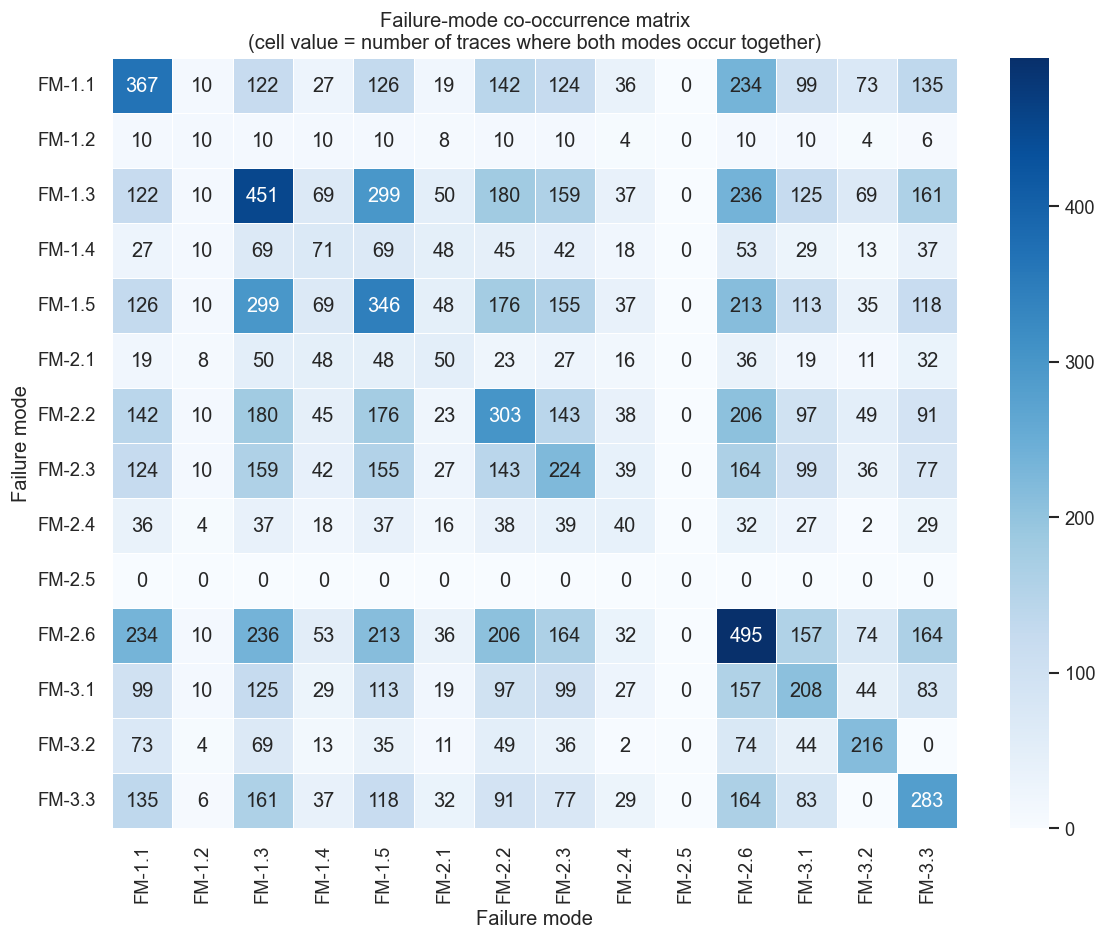

Diagonal (= how often each FM appears on its own):
FM-2.6    495
FM-1.3    451
FM-1.1    367
FM-1.5    346
FM-2.2    303
FM-3.3    283
FM-2.3    224
FM-3.2    216
FM-3.1    208
FM-1.4     71
FM-2.1     50
FM-2.4     40
FM-1.2     10
FM-2.5      0
dtype: int64


In [14]:
failed_traces = df.loc[df["any_failure"], FM_COLS]
cooccurrence = failed_traces.T.dot(failed_traces)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cooccurrence,
    annot=True,        # write the number inside each cell
    fmt="d",           # "d" = integer format (no decimals)
    cmap="Blues",      # darker blue = more co-occurrences
    linewidths=0.4,    # thin grid lines between cells
    ax=ax,
)

ax.set_title("Failure-mode co-occurrence matrix\n(cell value = number of traces where both modes occur together)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Failure mode")
plt.tight_layout()
plt.savefig("fig_fm_cooccurrence.png")
plt.show()

print("Diagonal (= how often each FM appears on its own):")
print(pd.Series(cooccurrence.values.diagonal(), index=cooccurrence.index).sort_values(ascending=False))

## 4. Trace Length Distributions (Tokens)

In [10]:
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(enc.encode(text))

print("Computing token counts...")
df["tokens"] = df["trajectory"].apply(count_tokens)
print("Done.")

df[["framework", "tokens"]].describe()

Computing token counts...
Done.


,tokens
count,1242.000000
mean,12076.438808
std,21242.802341
min,296.000000
25%,1115.250000
50%,1842.000000
75%,11769.750000
max,176380.000000


C:\Users\bramn\AppData\Local\Temp\ipykernel_31880\553950951.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_fw, labels=frameworks, showfliers=False)


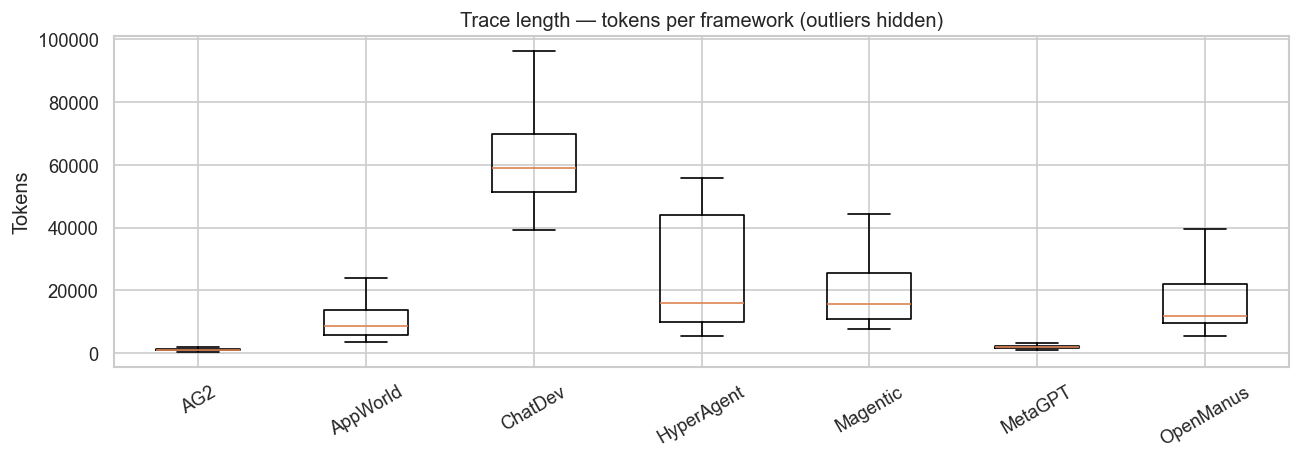

In [11]:
frameworks = sorted(df["framework"].unique())

fig, ax = plt.subplots(figsize=(11, 4))

data_by_fw = [df.loc[df["framework"] == fw, "tokens"].values for fw in frameworks]
ax.boxplot(data_by_fw, labels=frameworks, showfliers=False)
ax.set_title("Trace length — tokens per framework (outliers hidden)")
ax.set_ylabel("Tokens")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_trace_length_distributions.png")
plt.show()

## 5. Step Length and Message-Kind Distribution per Framework

Uses the MAD-specific parsers from `parsers/*` to get structured `Trace` objects with typed `Step` kinds (`message`, `tool_call`, `tool_result`, `system`).

In [ ]:
PARSERS_ROOT = (Path('..') / 'parsers').resolve()
MAD_JSON = (Path('..') / 'data' / 'MAST-Data' / 'MAD_full_dataset.json').resolve()
sys.path.insert(0, str(PARSERS_ROOT))

def _load_parser(name, rel_path):
    path = PARSERS_ROOT / rel_path
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_ag2        = _load_parser("p_ag2",        "ag2_parser/ag2_parser.py")
_appworld   = _load_parser("p_appworld",   "appworld_parser/appworld_parser.py")
_chatdev    = _load_parser("p_chatdev",    "chatdev_parser/chatdev_parser.py")
_hyperagent = _load_parser("p_hyperagent", "hyperagent_parser/hyperagent_parser.py")
_magentic   = _load_parser("p_magentic",   "magenticone_parser/magenticone_parser.py")
_metagpt    = _load_parser("p_metagpt",    "metagpt_parser/metagpt_parser.py")
_openmanus  = _load_parser("p_openmanus",  "openmanus_parser/openmanus_parser.py")

with open(MAD_JSON) as f:
    _mad_data = json.load(f)

def _parse_appworld():
    traces = []
    for rec in _mad_data:
        if rec['mas_name'] != 'AppWorld':
            continue
        with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', encoding='utf-8', delete=False) as tmp:
            tmp.write(rec['trace']['trajectory'])
            tmp_path = Path(tmp.name)
        try:
            t = _appworld.parse_file(tmp_path)
            t.metadata.update({
                'mad_trace_key': rec['trace']['key'],
                'mas_name': 'AppWorld',
                'llm_name': rec['llm_name'],
                'benchmark_name': rec['benchmark_name'],
                'mast_annotation': rec['mast_annotation'],
            })
            traces.append(t)
        finally:
            tmp_path.unlink(missing_ok=True)
    return traces

def _parse_chatdev():
    traces = []
    for rec in _mad_data:
        if rec['mas_name'] != 'ChatDev':
            continue
        t = _chatdev.parse_log_text(rec['trace']['trajectory'], trace_id=str(rec['trace_id']))
        t.metadata.update({
            'mad_trace_key': rec['trace']['key'],
            'mas_name': 'ChatDev',
            'llm_name': rec['llm_name'],
            'benchmark_name': rec['benchmark_name'],
            'mast_annotation': rec['mast_annotation'],
        })
        traces.append(t)
    return traces

print("Parsing all frameworks…")
all_traces = (
    _ag2.parse_all(MAD_JSON)        +
    _parse_appworld()               +
    _parse_chatdev()                +
    _hyperagent.parse_all(MAD_JSON) +
    _magentic.parse_all(MAD_JSON)   +
    _metagpt.parse_all(MAD_JSON)    +
    _openmanus.parse_all(MAD_JSON)
)
n_fw = len({t.metadata['mas_name'] for t in all_traces})
print(f"Total parsed: {len(all_traces)} traces across {n_fw} frameworks")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\bramn\\Desktop\\Thesis\\agent-evaluation-framework\\parsers\\ag2_parser\\mad\\ag2_parser.py'

C:\Users\bramn\AppData\Local\Temp\ipykernel_31988\435232663.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([step_counts[fw] for fw in frameworks_ord], labels=frameworks_ord, showfliers=False)


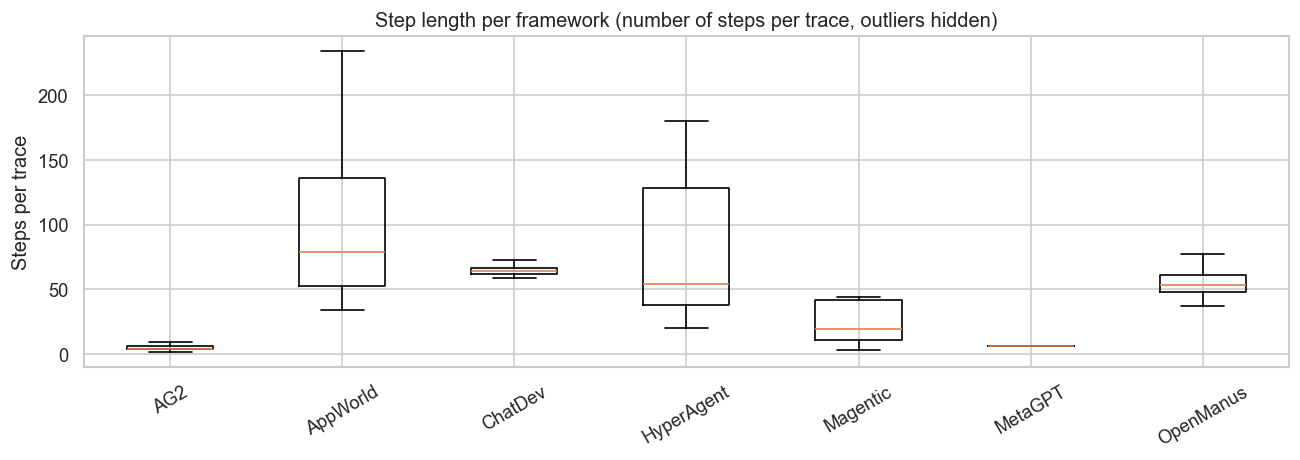


Median / mean / max steps per framework:
  AG2            : median=    4  mean=   5.2  max=28
  AppWorld       : median=   79  mean= 113.6  max=523
  ChatDev        : median=   64  mean=  66.2  max=103
  HyperAgent     : median=   54  mean= 110.1  max=535
  Magentic       : median=   19  mean=  24.9  max=44
  MetaGPT        : median=    6  mean=   6.0  max=6
  OpenManus      : median=   54  mean=  54.7  max=86


In [ ]:
step_counts = {}
for t in all_traces:
    fw = t.metadata.get('mas_name', 'Unknown')
    step_counts.setdefault(fw, []).append(len(t.steps))

frameworks_ord = sorted(step_counts)

fig, ax = plt.subplots(figsize=(11, 4))
ax.boxplot([step_counts[fw] for fw in frameworks_ord], labels=frameworks_ord, showfliers=False)
ax.set_title("Step length per framework (number of steps per trace, outliers hidden)")
ax.set_ylabel("Steps per trace")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_step_length_per_framework.png")
plt.show()

print("\nMedian / mean / max steps per framework:")
for fw in frameworks_ord:
    arr = np.array(step_counts[fw])
    print(f"  {fw:15s}: median={np.median(arr):5.0f}  mean={np.mean(arr):6.1f}  max={arr.max()}")

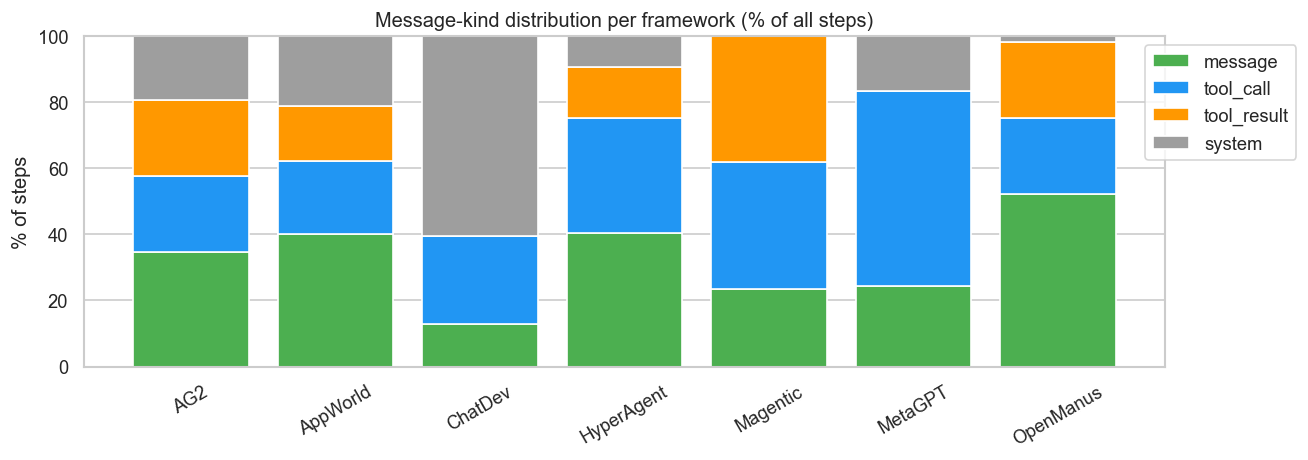


Raw step counts per framework and kind:
            message  tool_call  tool_result  system
AG2            1077        717          717     597
AppWorld       1366        755          563     724
ChatDev        1113       2283            0    5207
HyperAgent     1250       1069          481     283
Magentic       1142       1862         1849       0
MetaGPT         335        809            0     230
OpenManus       857        379          379      27


In [ ]:
KINDS = ['message', 'tool_call', 'tool_result', 'system']
COLORS = ['#4CAF50', '#2196F3', '#FF9800', '#9E9E9E']

kind_counts = {fw: Counter() for fw in frameworks_ord}
for t in all_traces:
    fw = t.metadata.get('mas_name', 'Unknown')
    for s in t.steps:
        kind_counts[fw][s.kind] += 1

kind_df = pd.DataFrame(
    {fw: {k: kind_counts[fw].get(k, 0) for k in KINDS} for fw in frameworks_ord}
).T
kind_pct = kind_df.div(kind_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(frameworks_ord))
for kind, color in zip(KINDS, COLORS):
    vals = kind_pct[kind].values
    ax.bar(frameworks_ord, vals, bottom=bottom, label=kind, color=color)
    bottom += vals

ax.set_title("Message-kind distribution per framework (% of all steps)")
ax.set_ylabel("% of steps")
ax.tick_params(axis="x", rotation=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.13, 1))
plt.tight_layout()
plt.savefig("fig_message_kind_distribution.png")
plt.show()

print("\nRaw step counts per framework and kind:")
print(kind_df.to_string())